# Model comparisons of counterfactual order effects

This notebook evaluates model fits to the experimental data in `../../../data/data_2/experiment_2.csv` as a robustness check for conclusions about classes of sequential counterfactual inference.

## Models to evaluate

We compare models along three dimensions:

- **Inference type**
    - **Backtracking**: $s < 1$
    - **Interventional (Pearl-like)**: $s = 1$

- **Memory / sequential dependence**
    - **Memoryless**: $p_{keep} = 0$
    - **Sequential**: $0 < p_{keep} < 1$
    - **Sequential-hard**: $ p_{keep} = 1$

- **Structural parameterization** (base rates and causal powers)

### Structural families and parameter sets

Let the original 8 structural parameters be:

$$
\beta_A,\; \beta_B,\; \beta_C,\; \beta_D,\; \theta_{AB},\; \theta_{AC},\; \theta_{BD},\; \theta_{CD}.
$$


For each family below, we list free parameters and how they determine all 8 original parameters.

- **`br`**: free parameters $\phi = [\mathrm{br}]$
  - $ \beta_A = \beta_B = \beta_C = \beta_D = \mathrm{br}$
  - $\theta_{AB} = \theta_{AC} = \theta_{BD} = \theta_{CD} = 1-\mathrm{br}$

- **`br_cp`**: free parameters $\phi = [\mathrm{br},\; \mathrm{causal\_power}]$
    - $\beta_A = \beta_B = \beta_C = \beta_D = \mathrm{br}$
    - $\theta_{AB} = \theta_{AC} = \theta_{BD} = \theta_{CD} = \mathrm{causal\_power}$

- **`br_source_target`**: free parameters $\phi = [\mathrm{br},\; \mathrm{cp\_source},\; \mathrm{cp\_target}]$
    - $\beta_A = \beta_B = \beta_C = \beta_D = \mathrm{br}$
    - $\theta_{AB} = \theta_{AC} = \mathrm{cp\_source}$
    - $\theta_{BD} = \theta_{CD} = \mathrm{cp\_target}$

- **`betas_source_target`**: free parameters $\phi = [\beta_B,\; \beta_C,\; \beta_A,\; \beta_D,\; \mathrm{cp\_source},\; \mathrm{cp\_target}]$
    - $(\beta_A,\beta_B,\beta_C,\beta_D)$ are free
    - $\theta_{AB} = \theta_{AC} = \mathrm{cp\_source}$
    - $\theta_{BD} = \theta_{CD} = \mathrm{cp\_target}$

- **`betas_cp`**: free parameters $\phi = [\beta_B,\; \beta_C,\; \beta_A,\; \beta_D,\; \mathrm{causal\_power}]$
    - $(\beta_A,\beta_B,\beta_C,\beta_D)$ are free
    - $\theta_{AB} = \theta_{AC} = \theta_{BD} = \theta_{CD} = \mathrm{causal\_power}$

- **`full`**: free parameters $\phi = [\beta_B,\; \beta_C,\; \beta_A,\; \beta_D,\; \theta_{AB},\; \theta_{AC},\; \theta_{BD},\; \theta_{CD}]$
    - $\beta_A,\beta_B,\beta_C,\beta_D,\theta_{AB},\theta_{AC},\theta_{BD},\theta_{CD}$ all free

- **`BC`**: free parameters $\phi = [\mathrm{br},\; \beta_A,\; \beta_D]$
    - $\beta_B = \beta_C = \mathrm{br}$
    - $\beta_A,\beta_D$ are free
    - $\theta_{AB} = \theta_{AC} = \theta_{BD} = \theta_{CD} = 1-\mathrm{br}$

- **`BC_cp`**: free parameters $\phi = [\mathrm{br},\; \beta_A,\; \beta_D,\; \mathrm{causal\_power}]$
    - $\beta_B = \beta_C = \mathrm{br}$
    - $\beta_A,\beta_D$ are free
    - $\theta_{AB} = \theta_{AC} = \theta_{BD} = \theta_{CD} = \mathrm{causal\_power}$

- **`BC_source_target`**: free parameters $\phi = [\mathrm{br},\; \beta_A,\; \beta_D,\; \mathrm{cp\_source},\; \mathrm{cp\_target}]$
    - $\beta_B = \beta_C = \mathrm{br}$
    - $\beta_A,\beta_D$ are free
    - $\theta_{AB} = \theta_{AC} = \mathrm{cp\_source}$
    - $\theta_{BD} = \theta_{CD} = \mathrm{cp\_target}$

- **`BC_full`**: free parameters $\phi = [\mathrm{br},\; \beta_A,\; \beta_D,\; \theta_{AB},\; \theta_{AC},\; \theta_{BD},\; \theta_{CD}]$
    - $\beta_B = \beta_C = \mathrm{br}$
    - $\beta_A,\beta_D$ are free
    - $\theta_{AB},\theta_{AC},\theta_{BD},\theta_{CD}$ are all free

Altogether we are left with 60 models to evaluate (10 structural $\times$ 6 counterfactual inference ablations).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
import os

sys.path.append(os.path.abspath('..'))

from CfModels.order_methods import static_twin_with_missing

## Import all Data

- Experimental data
- Cross validated fits
- Full data fits

In [2]:
# Experiment data
exp2_data = pd.read_csv('../../../data/data_2/experiment_2.csv')

# Cross validation data load
import glob
import pickle

results_dir = '../../../data/model_fits/'

# Load all cross-validation pickle files
# cv_files = glob.glob(results_dir + 'cross_validation/exp2_cond_l-bfgs-b/*.pkl')
cv_files = glob.glob(results_dir + 'cross_validation/exp2_cond_bfgs/*.pkl')

cv_results = {}
for file_path in cv_files:
    # Extract the filename without path and extension
    filename = file_path.split('/')[-1].replace('.pkl', '')
    # trim exp2_xval_ from the start
    filename = filename.replace('exp2_xval_', '')

    # skip if 'power' or '_.pkl' in filename
    if 'power' in filename or filename[-1] == '_' or 'summary' in filename:
        continue
    
    # Load the pickle file
    with open(file_path, 'rb') as f:
        cv_results[filename] = pickle.load(f)
print(f"Loaded {len(cv_results)} cross-validation results.")

# Load all the fit files:
fit_files = glob.glob(results_dir + 'fits/exp2_bfgs/*.pkl')

fit_results_bfgs = {}
for file_path in fit_files:
    # Extract the filename without path and extension
    filename = file_path.split('/')[-1].replace('.pkl', '')
    # trim exp2_fit_ from the start
    filename = filename.replace('exp2_fit_', '')
    
    # Load the pickle file
    with open(file_path, 'rb') as f:
        fit_results_bfgs[filename] = pickle.load(f)
print(f"Loaded {len(fit_results_bfgs)} fitting results.")



Loaded 60 cross-validation results.
Loaded 60 fitting results.


## Model Comparisons

Here we compute the evaluation metrics for each of the models described above.

Metrics:
- AIC
- BIC
- Cross-validation (CV-NLL)

Note that the CV-NLL score is the average negative log-likelihood score of the model across the cross validation folds.

In [3]:
# n_data = len(exp2_data)*3 # 3 responses per participant
n_data = (exp2_data[['A', 'C', 'D']].apply(abs).values.flatten()>0).sum() # only count non-zero responses

model_comparison = {}
for model,fit_data in fit_results_bfgs.items():
    if model in cv_results:
        fit = fit_results_bfgs[model]
        cv = cv_results[model]
        nll = fit['nll']
        k = fit['optimization_result'].x.shape[0]
        aic = 2*nll + 2*k
        bic = 2*nll + k*np.log(n_data)
        model_comparison[model] = {
            'fit_nll': nll,
            'cv_nll': np.mean(cv['test_nlls']),
            'n_params': fit['optimization_result'].x.shape[0],
            'aic': aic,
            'bic': bic
        }

In [4]:
model_comparison_df = pd.DataFrame.from_dict(model_comparison, orient='index')
model_comparison_df.reset_index(inplace=True)
model_comparison_df.rename(columns={'index': 'model'}, inplace=True)
model_comparison_df = model_comparison_df.sort_values(by='cv_nll')
model_comparison_df

,model,fit_nll,cv_nll,n_params,aic,bic
53,BC_full,502.028785,64.623195,10,1024.057571,1071.101714
59,BC_source_target,503.693959,64.998147,8,1023.387918,1061.023233
45,BC_source_target_p1,509.206927,64.998543,7,1032.413853,1065.344754
39,betas_cp,504.173172,65.073629,8,1024.346344,1061.981659
31,betas_source_target,502.962185,65.287448,9,1023.924370,1066.264099
6,full,502.047813,65.559035,11,1026.095627,1077.844185
44,BC_p1,518.488499,65.755132,5,1046.976997,1070.499069
32,BC_cp_p1,515.526733,65.896866,6,1043.053466,1071.279952
57,BC_cp,508.014135,65.932563,7,1030.028270,1062.959171
49,betas_cp_p1,514.050581,66.184827,7,1042.101161,1075.032062


In [5]:
# Best fitting aic models
model_comparison_df.sort_values(by='aic').head(5)

,model,fit_nll,cv_nll,n_params,aic,bic
59,BC_source_target,503.693959,64.998147,8,1023.387918,1061.023233
31,betas_source_target,502.962185,65.287448,9,1023.924370,1066.264099
53,BC_full,502.028785,64.623195,10,1024.057571,1071.101714
39,betas_cp,504.173172,65.073629,8,1024.346344,1061.981659
6,full,502.047813,65.559035,11,1026.095627,1077.844185


In [6]:
# Best fitting bic models
model_comparison_df.sort_values(by='bic').head(5)

,model,fit_nll,cv_nll,n_params,aic,bic
59,BC_source_target,503.693959,64.998147,8,1023.387918,1061.023233
39,betas_cp,504.173172,65.073629,8,1024.346344,1061.981659
57,BC_cp,508.014135,65.932563,7,1030.028270,1062.959171
3,BC,511.489888,77.664778,6,1034.979777,1063.206263
45,BC_source_target_p1,509.206927,64.998543,7,1032.413853,1065.344754


In [7]:
# best fitting models cv_nll
model_comparison_df.head(5)

,model,fit_nll,cv_nll,n_params,aic,bic
53,BC_full,502.028785,64.623195,10,1024.057571,1071.101714
59,BC_source_target,503.693959,64.998147,8,1023.387918,1061.023233
45,BC_source_target_p1,509.206927,64.998543,7,1032.413853,1065.344754
39,betas_cp,504.173172,65.073629,8,1024.346344,1061.981659
31,betas_source_target,502.962185,65.287448,9,1023.924370,1066.264099


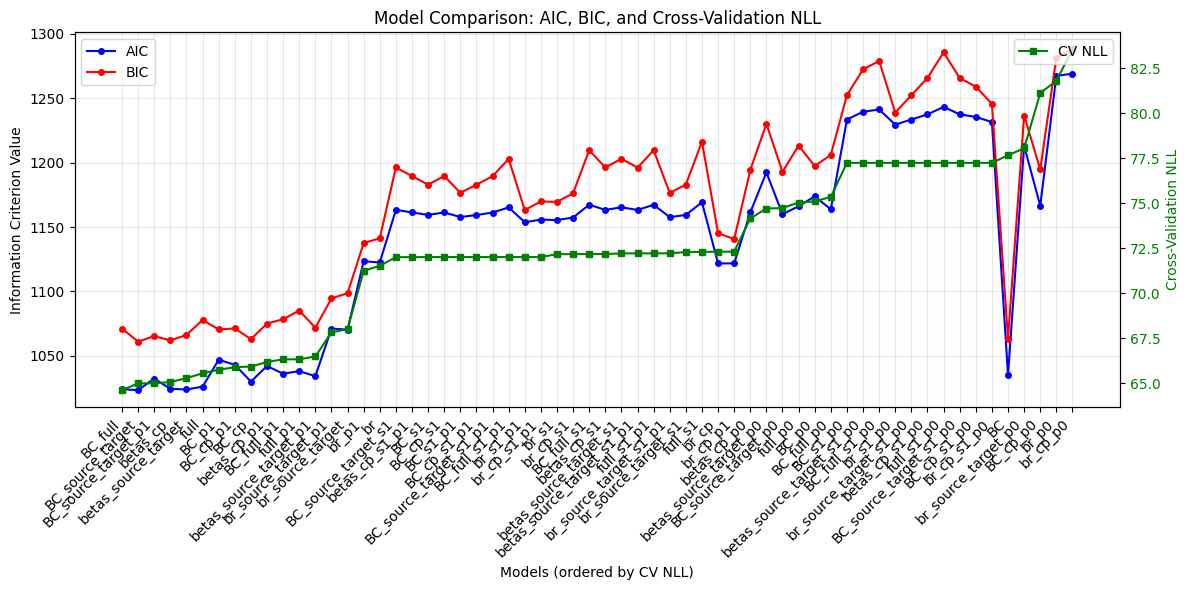

In [8]:
fig, ax1 = plt.subplots(1, 1, figsize=(12, 6))

# Plot AIC and BIC on the primary y-axis
ax1.plot(range(len(model_comparison_df)), model_comparison_df['aic'], 'b-o', markersize=4, label='AIC')
ax1.plot(range(len(model_comparison_df)), model_comparison_df['bic'], 'r-o', markersize=4, label='BIC')
ax1.set_ylabel('Information Criterion Value', color='black')
ax1.set_xlabel('Models (ordered by CV NLL)')
ax1.grid(True, alpha=0.3)

# Create secondary y-axis for CV NLL
ax2 = ax1.twinx()
ax2.plot(range(len(model_comparison_df)), model_comparison_df['cv_nll'], 'g-s', markersize=4, label='CV NLL')
ax2.set_ylabel('Cross-Validation NLL', color='g')
ax2.tick_params(axis='y', labelcolor='g')

# Set x-axis labels with model names (rotated for readability)
ax1.set_xticks(range(len(model_comparison_df)))
ax1.set_xticklabels(model_comparison_df['model'], rotation=45, ha='right')

# Add legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

ax1.set_title('Model Comparison: AIC, BIC, and Cross-Validation NLL')
plt.tight_layout()
plt.show()


In [9]:
# Get top 3 models by each criterion
top_aic = model_comparison_df.nsmallest(3, 'aic')['model'].tolist()
top_bic = model_comparison_df.nsmallest(3, 'bic')['model'].tolist()
top_cv = model_comparison_df.nsmallest(3, 'cv_nll')['model'].tolist()

# Combine all top models (remove duplicates)
top_models = list(set(top_aic + top_bic + top_cv))

# Filter dataframe to only include top models
top_models_df = model_comparison_df[model_comparison_df['model'].isin(top_models)]
top_models_df = top_models_df.sort_values(by='cv_nll')
top_models_df

,model,fit_nll,cv_nll,n_params,aic,bic
53,BC_full,502.028785,64.623195,10,1024.057571,1071.101714
59,BC_source_target,503.693959,64.998147,8,1023.387918,1061.023233
45,BC_source_target_p1,509.206927,64.998543,7,1032.413853,1065.344754
39,betas_cp,504.173172,65.073629,8,1024.346344,1061.981659
31,betas_source_target,502.962185,65.287448,9,1023.924370,1066.264099
57,BC_cp,508.014135,65.932563,7,1030.028270,1062.959171


The best performing model in the cross-validation analysis was the `BC_full` model.
This is the structural assumption that we report on in the paper and conduct the subsequent inference class analysis with this structural assumption.

## Testing inference class across structural assumptions

In the paper we report the `BC_full` structural assumptions and compare models with different counterfactual inference methods:
- Sequential
- Memoryless
- Backtracking
- Interventional

Here we will show the overall performances of these inference classes across all 10 structural assumptions.
This is a robustness check to validate whether the inference classes are consistently performing the same if we make different structural assumptions.

In [10]:
pearl_p = model_comparison_df[(model_comparison_df['model'].isin(['s1'])) & ~(model_comparison_df['model']).isin(['p0'])]
pearl_p0 = model_comparison_df[(model_comparison_df['model'].isin(['s1_p0']))]
backtracking_p = model_comparison_df[~(model_comparison_df['model'].isin(['s1'])) & ~(model_comparison_df['model']).isin(['p0'])]
backtracking_p0 = model_comparison_df[~(model_comparison_df['model'].isin(['s1'])) & (model_comparison_df['model']).isin(['p0'])]

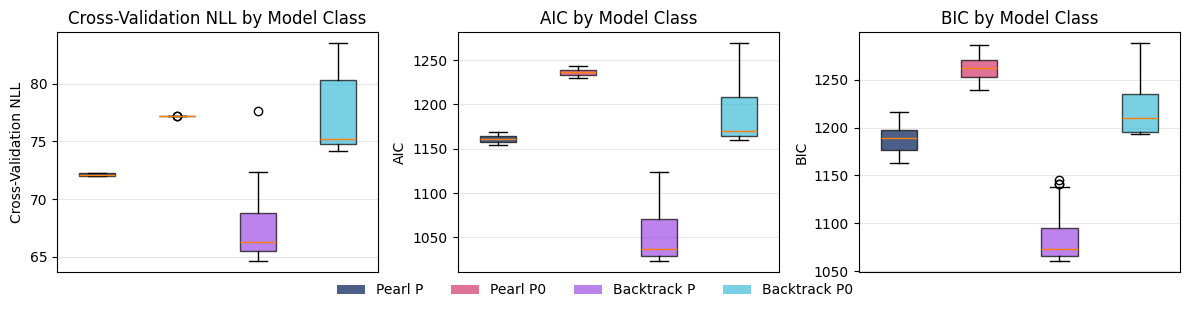

In [11]:
# Create figure with 3 subplots for the boxplots
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# Define the metrics and their labels
metrics = ['cv_nll', 'aic', 'bic']
metric_labels = ['Cross-Validation NLL', 'AIC', 'BIC']

# Use the colorblind-friendly palette
colors = ['#001C55',
            '#d2376b',
            '#A14EE4',
            '#40BCD8']

# Create the model groups with proper filtering
# Pearl models: contain 's1' but not 'p0'
pearl_p = model_comparison_df[model_comparison_df['model'].str.contains('s1') & 
                             ~model_comparison_df['model'].str.contains('p0')]

# Pearl p0 models: contain both 's1' and 'p0'
pearl_p0 = model_comparison_df[model_comparison_df['model'].str.contains('s1') & 
                              model_comparison_df['model'].str.contains('p0')]

# Backtracking models: don't contain 's1' and don't contain 'p0'
backtracking_p = model_comparison_df[~model_comparison_df['model'].str.contains('s1') & 
                                   ~model_comparison_df['model'].str.contains('p0')]

# Backtracking p0 models: don't contain 's1' but contain 'p0'
backtracking_p0 = model_comparison_df[~model_comparison_df['model'].str.contains('s1') & 
                                    model_comparison_df['model'].str.contains('p0')]

# For each metric, create a boxplot
for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[i]
    
    # Prepare data for boxplot
    data = []
    labels = []
    box_colors = []
    
    # Add all four groups
    if len(pearl_p) > 0:
        data.append(pearl_p[metric].values)
        labels.append('Pearl P')
        box_colors.append(colors[0])
    
    if len(pearl_p0) > 0:
        data.append(pearl_p0[metric].values)
        labels.append('Pearl P0')
        box_colors.append(colors[1])
        
    if len(backtracking_p) > 0:
        data.append(backtracking_p[metric].values)
        labels.append('Backtrack P')
        box_colors.append(colors[2])
    
    if len(backtracking_p0) > 0:
        data.append(backtracking_p0[metric].values)
        labels.append('Backtrack P0')
        box_colors.append(colors[3])
    
    # Create boxplot with colors
    if data:  # Only plot if we have data
        bp = ax.boxplot(data, patch_artist=True)
        
        # Apply colors to boxes
        for patch, color in zip(bp['boxes'], box_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_title(f'{label} by Model Class')
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3)
        
        # Remove x-axis labels since we'll have a legend
        ax.set_xticks([])
        
    else:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{label} by Model Class')

# Add single legend below all plots
legend_elements = [plt.Rectangle((0,0),1,1, facecolor=color, alpha=0.7) 
                  for color in colors]
legend_labels = ['Pearl P', 'Pearl P0', 'Backtrack P', 'Backtrack P0']

fig.legend(legend_elements, legend_labels, loc='lower center', 
           bbox_to_anchor=(0.5, -0.05), ncol=4, frameon=False)

plt.tight_layout()
plt.show()

The sequential backtracking model is robustly a better model of participant data across several structural assumptions.